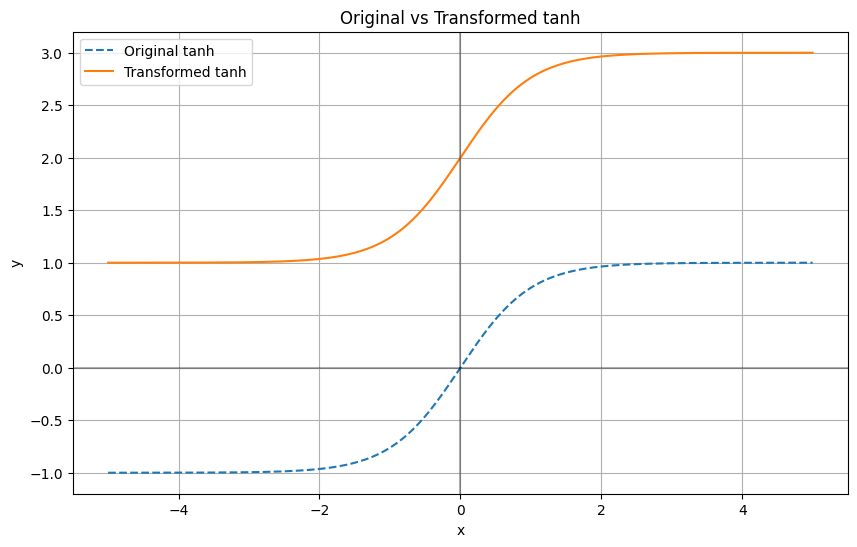

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Create input values
x = np.linspace(-5, 5, 200)

# Original tanh
y_original = np.tanh(x)

# Transformed tanh with your parameters
vertical_scaling = 1
horizontal_scaling = 1
vertical_shift = 2
y_transformed = vertical_shift + vertical_scaling * np.tanh(x / horizontal_scaling)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y_original, label='Original tanh', linestyle='--')
plt.plot(x, y_transformed, label='Transformed tanh')
plt.grid(True)
plt.legend()
plt.title('Original vs Transformed tanh')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.show()

/var/folders/48/l13wwcrn4g34_y7bgnwynx7c0000gn/T/ipykernel_23052/1500058599.py:76: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


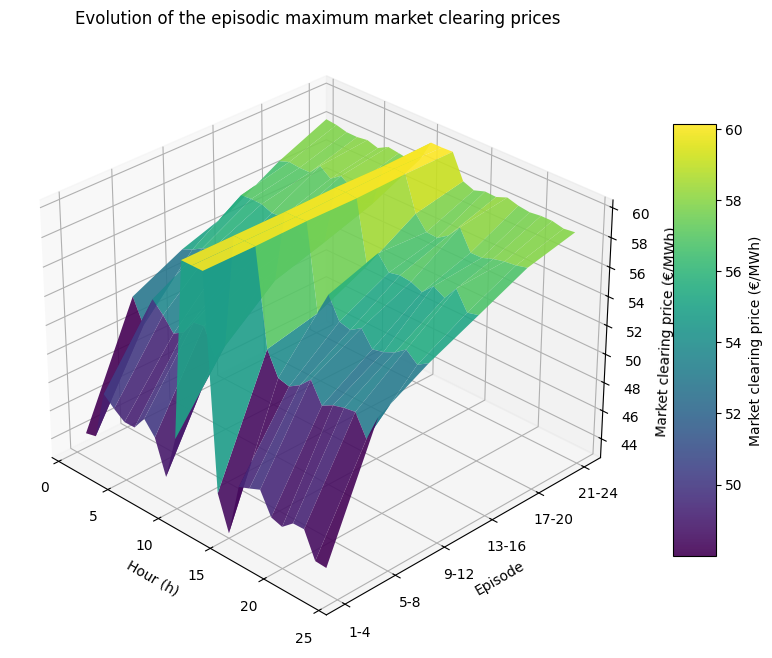

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Load the saved episode data from the specified path
episode_data = torch.load('/Users/andrewsmith/Documents/projects/rl-power-markets/episode_data.pt').detach()

# truncate first 30 episodes
episode_data = episode_data

# Extract the market clearing prices (first channel of the data)
# Shape: (episodes, hours)
prices = episode_data[:, :, 0].detach().numpy()

# Define the number of episodes and hours
num_episodes = prices.shape[0]
num_hours = prices.shape[1]

# Create episode bins for visualization (similar to the paper)
# We'll create 6 bins as shown in the figure
bin_size = num_episodes // 6
episode_bins = []
bin_labels = []

for i in range(6):
    start_idx = i * bin_size
    end_idx = min((i+1) * bin_size, num_episodes)
    
    # Calculate maximum prices for this bin (instead of mean)
    bin_max_prices = np.max(prices[start_idx:end_idx], axis=0)
    episode_bins.append(bin_max_prices)
    
    # Create label for this bin
    bin_labels.append(f'{start_idx+1}-{end_idx}')

# Create meshgrid for 3D surface
hours = np.arange(1, num_hours + 1)
bin_indices = np.arange(len(episode_bins))
X, Y = np.meshgrid(hours, bin_indices)

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a single 3D surface with color based on price
Z = np.array(episode_bins)

# Plot the surface with color based on price values
surf = ax.plot_surface(
    X, Y, Z, 
    cmap='viridis',  # Use a colormap that transitions well for prices
    edgecolor='none',
    alpha=0.9,
    antialiased=True
)

# Set labels and title
ax.set_xlabel('Hour (h)')
ax.set_ylabel('Episode')
ax.set_zlabel('Market clearing price (€/MWh)')
ax.set_title('Evolution of the episodic maximum market clearing prices')

# Set y-ticks to show bin labels
ax.set_yticks(np.arange(len(episode_bins)))
ax.set_yticklabels(bin_labels)

# Adjust view angle to match the paper
ax.view_init(elev=30, azim=-45)

# Add a colorbar to show the price scale
cbar = fig.colorbar(surf, ax=ax, shrink=0.7, aspect=10)
cbar.set_label('Market clearing price (€/MWh)')

plt.tight_layout()
plt.show()

/var/folders/48/l13wwcrn4g34_y7bgnwynx7c0000gn/T/ipykernel_23052/2158722498.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['{:.1f}'.format(x/1000) for x in current_values])


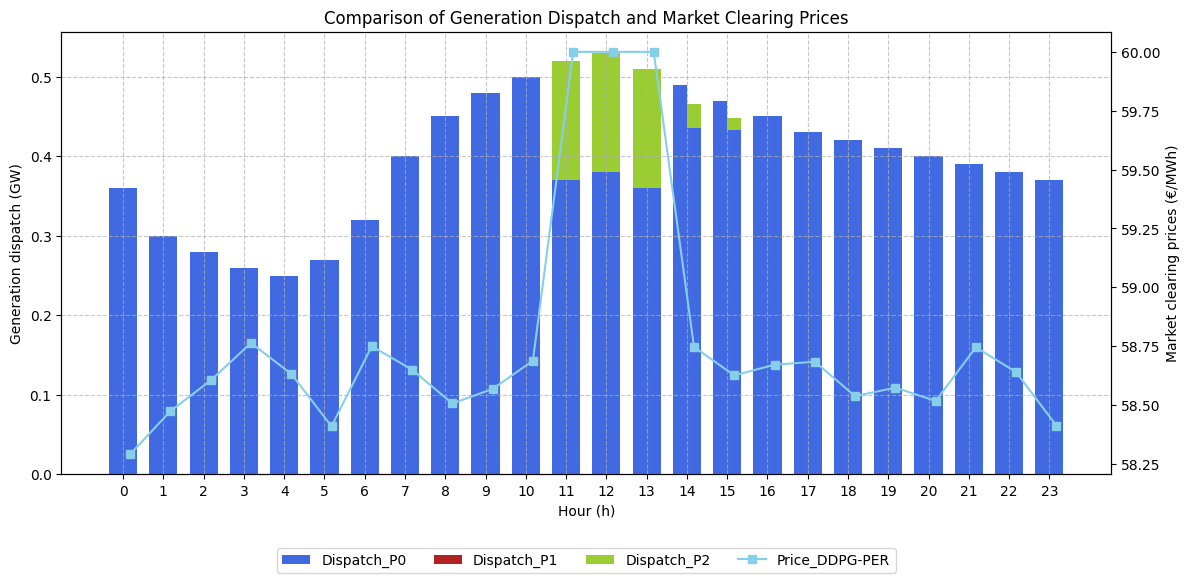

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load the saved episode data from the specified path
episode_data = torch.load('/Users/andrewsmith/Documents/projects/rl-power-markets/episode_data.pt').detach()

# Extract the data
# Shape: (episodes, hours, 4) where 4 represents [price, dispatch_p0, dispatch_p1, dispatch_p2]
prices = episode_data[:, :, 0]
dispatch_p0 = episode_data[:, :, 1]  # Strategic producer (P5 in the figure)
dispatch_p1 = episode_data[:, :, 2]  # Non-strategic producer 1 (P6 in the figure)
dispatch_p2 = episode_data[:, :, 3]  # Non-strategic producer 2 (P7 in the figure)

# Select the last episode for DDPG-PER results (assuming it's the best trained model)
last_episode_idx = -1
ddpg_prices = prices[last_episode_idx].numpy()
ddpg_dispatch_p0 = dispatch_p0[last_episode_idx].numpy()
ddpg_dispatch_p1 = dispatch_p1[last_episode_idx].numpy()
ddpg_dispatch_p2 = dispatch_p2[last_episode_idx].numpy()

# Select the first episode for baseline comparison (DQN in the figure)
# This is just a placeholder - you might want to use a different baseline
first_episode_idx = 0
dqn_prices = prices[first_episode_idx].numpy()
dqn_dispatch_p0 = dispatch_p0[first_episode_idx].numpy()
dqn_dispatch_p1 = dispatch_p1[first_episode_idx].numpy()
dqn_dispatch_p2 = dispatch_p2[first_episode_idx].numpy()

# Select specific hours to display (hours 12-16 in the figure)
selected_hours = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
hour_indices = [h-1 for h in selected_hours]  # Convert to 0-based indexing

# Create the figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Set width of bars
bar_width = 0.35
index = np.arange(len(selected_hours))

# Plot stacked bars for DQN dispatch
p1_dqn = ax1.bar(index, dqn_dispatch_p0[hour_indices], bar_width, 
                 label='Dispatch_P0 (DQN)', color='royalblue')
p2_dqn = ax1.bar(index, dqn_dispatch_p1[hour_indices], bar_width, 
                 bottom=dqn_dispatch_p0[hour_indices], label='Dispatch_P1 (DQN)', color='firebrick')
p3_dqn = ax1.bar(index, dqn_dispatch_p2[hour_indices], bar_width, 
                 bottom=dqn_dispatch_p0[hour_indices] + dqn_dispatch_p1[hour_indices], 
                 label='Dispatch_P2 (DQN)', color='yellowgreen')

# Plot stacked bars for DDPG-PER dispatch
p1_ddpg = ax1.bar(index + bar_width, ddpg_dispatch_p0[hour_indices], bar_width, 
                  label='Dispatch_P0 (DDPG-PER)', color='royalblue')
p2_ddpg = ax1.bar(index + bar_width, ddpg_dispatch_p1[hour_indices], bar_width, 
                  bottom=ddpg_dispatch_p0[hour_indices], label='Dispatch_P1 (DDPG-PER)', color='firebrick')
p3_ddpg = ax1.bar(index + bar_width, ddpg_dispatch_p2[hour_indices], bar_width, 
                  bottom=ddpg_dispatch_p0[hour_indices] + ddpg_dispatch_p1[hour_indices], 
                  label='Dispatch_P2 (DDPG-PER)', color='yellowgreen')

# Plot lines for prices
# line1 = ax2.plot(index, dqn_prices[hour_indices], marker='D', linestyle='-', 
#                  color='purple', label='Price_DQN')
line2 = ax2.plot(index + bar_width, ddpg_prices[hour_indices], marker='s', linestyle='-', 
                 color='skyblue', label='Price_DDPG-PER')

# Add labels, title and custom x-axis tick labels
ax1.set_xlabel('Hour (h)')
ax1.set_ylabel('Generation dispatch (MW)')
ax2.set_ylabel('Market clearing prices (€/MWh)')
ax1.set_title('Comparison of Generation Dispatch and Market Clearing Prices')
ax1.set_xticks(index + bar_width / 2)
ax1.set_xticklabels(selected_hours)

# Convert MW to GW for y-axis (if needed)
current_values = ax1.get_yticks()
ax1.set_yticklabels(['{:.1f}'.format(x/1000) for x in current_values])
ax1.set_ylabel('Generation dispatch (GW)')

# Add grid lines
ax1.grid(True, linestyle='--', alpha=0.7)

# Create combined legend
# First get handles and labels from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Create custom legend entries for the stacked bars
# We need to show only one entry per producer type
legend_handles = [p1_dqn[0], p2_dqn[0], p3_dqn[0], line2[0]]
legend_labels = ['Dispatch_P0', 'Dispatch_P1', 'Dispatch_P2', 'Price_DDPG-PER']

# Add the legend below the plot
ax1.legend(legend_handles, legend_labels, loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), ncol=5)

# Adjust layout to make room for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

plt.show()